## 1. Problem Definition

#### - Goal: Detect suspicious / fraudulent transactions

#### - Type: Binary Classification (Fraud vs Legit)  

## 2. Dataset
The dataset contains synthetic transaction records with details like amount, accounts, location, and payment type. 

In [28]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/berkanoztas/synthetic-transaction-monitoring-dataset-aml/SAML-D.csv")

print(f"\n Rows: {df.shape[0]:,} | Columns: {df.shape[1]}\n")
print(df.dtypes.to_frame("Dtype"))
print(df.head())


 Rows: 9,504,852 | Columns: 12

                          Dtype
Time                     object
Date                     object
Sender_account            int64
Receiver_account          int64
Amount                  float64
Payment_currency         object
Received_currency        object
Sender_bank_location     object
Receiver_bank_location   object
Payment_type             object
Is_laundering             int64
Laundering_type          object
       Time        Date  Sender_account  Receiver_account    Amount  \
0  10:35:19  2022-10-07      8724731955        2769355426   1459.15   
1  10:35:20  2022-10-07      1491989064        8401255335   6019.64   
2  10:35:20  2022-10-07       287305149        4404767002  14328.44   
3  10:35:21  2022-10-07      5376652437        9600420220  11895.00   
4  10:35:21  2022-10-07      9614186178        3803336972    115.25   

  Payment_currency Received_currency Sender_bank_location  \
0        UK pounds         UK pounds                   UK   
1 

## 3. Exploratory Data Analysis
- Checked class imbalance  
- Analyzed transaction amount distribution  

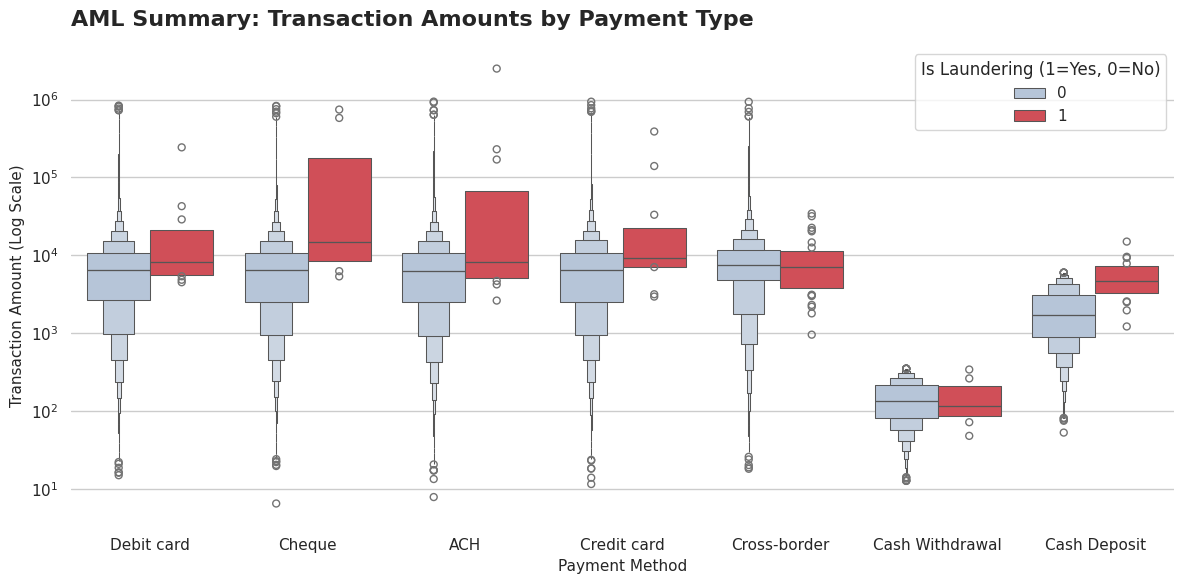

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Sampling is critical for large datasets to prevent memory crashes
df_sample = df.sample(n=100000, random_state=42) 

# 2. Set modern aesthetics
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 3. Boxenplot using your exact schema
ax = sns.boxenplot(
    data=df_sample, 
    x='Payment_type',
    y='Amount', 
    hue='Is_laundering',   
    palette={0: "lightsteelblue", 1: "#E63946"} # Blue for Normal, Red for Laundering
)

# 4. Clean up layout
ax.set_yscale('log') # Log scale handles massive outliers gracefully
plt.title("AML Summary: Transaction Amounts by Payment Type", fontsize=16, fontweight='bold', loc='left', pad=15)
plt.ylabel("Transaction Amount (Log Scale)", fontsize=11)
plt.xlabel("Payment Method", fontsize=11)

# Clean legend and borders
plt.legend(title="Is Laundering (1=Yes, 0=No)", frameon=True, facecolor='white')
sns.despine(left=True, bottom=True)
plt.tight_layout()

plt.show()

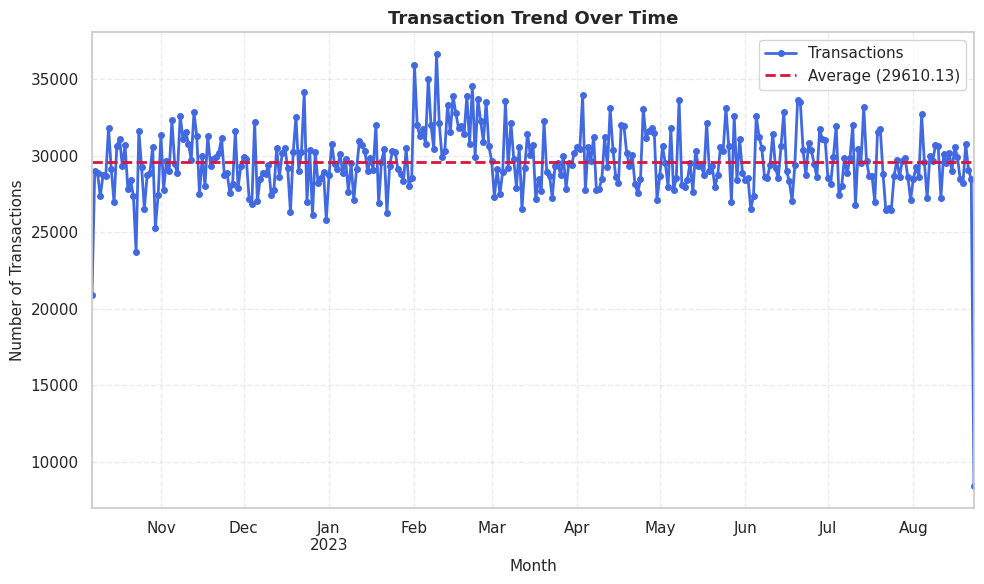

In [30]:
df['Date'] = pd.to_datetime(df['Date'])
monthly_transactions = df.groupby(df['Date'].dt.to_period('D')).size()

average_monthly_transactions = monthly_transactions.mean()

plt.figure(figsize=(10, 6))

# main line (transactions)
monthly_transactions.plot(kind='line',color='royalblue',linewidth=2,marker='o',markersize=4,label='Transactions')

# average line
plt.axhline(y=average_monthly_transactions,color='crimson',linestyle='--',linewidth=2,label=f'Average ({average_monthly_transactions:.2f})')

plt.xlabel('Month', fontsize=11)
plt.ylabel('Number of Transactions', fontsize=11)
plt.title('Transaction Trend Over Time', fontsize=13, fontweight='bold')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

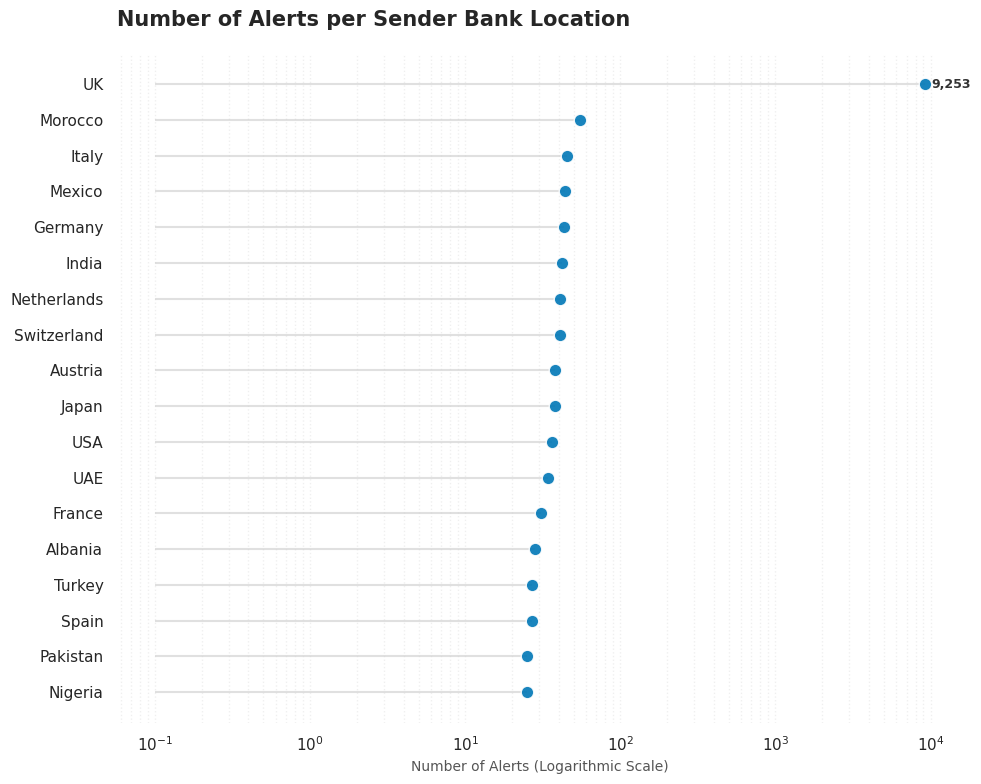

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare and Sort Data (Sorting is key for readability)
alerts = df.groupby('Sender_bank_location')['Is_laundering'].sum().sort_values()

# 2. Setup Figure
plt.figure(figsize=(10, 8), facecolor='white')
sns.set_style("white")

# 3. Create Lollipop Chart
# The 'stem'
plt.hlines(y=alerts.index, xmin=0.1, xmax=alerts.values, color='lightgray', alpha=0.7, lw=1.5)
# The 'marker'
plt.plot(alerts.values, alerts.index, "o", markersize=9, color='#0077b6', markeredgecolor='white', alpha=0.9)

# 4. The "Magic" Fix: Logarithmic Scale
# This handles the 0-100 and 8000+ gap perfectly in one view
plt.xscale('log')

# 5. Aesthetics & Labels
plt.title("Number of Alerts per Sender Bank Location", loc='left', fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Number of Alerts (Logarithmic Scale)", fontsize=10, color='#555555')
plt.ylabel("")

# Add subtle grid lines for the log scale
plt.grid(axis='x', which='both', linestyle=':', alpha=0.3)
sns.despine(left=True, bottom=True)

# Add data labels for the high-value outliers specifically
for i, v in enumerate(alerts.values): 
    if v > 1000: # Only label the big ones to keep it clean
        plt.text(v + (v*0.1), i, f'{v:,}', va='center', fontsize=9, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

### 📊 Laundering Type Distribution (Heatmap)

This heatmap shows the **proportion of suspicious vs normal transactions** across different laundering typologies.

- Values are **normalized (percentages)** to handle class imbalance  
- Helps identify **high-risk typologies** with more suspicious activity  
- Darker shades indicate **higher concentration of transactions**  

### 🔍 Insight
Certain typologies have a **higher percentage of suspicious transactions**, making them key indicators for fraud detection.

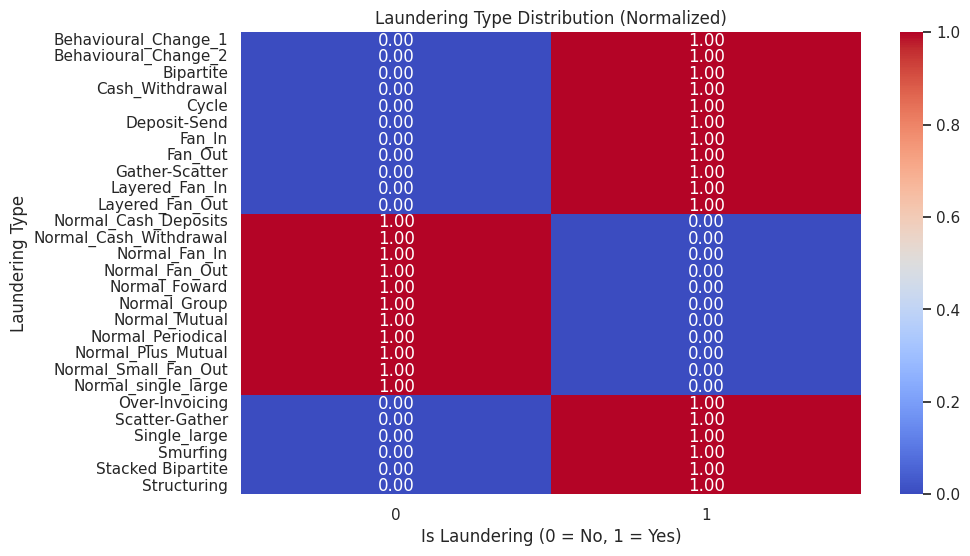

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create cross-tab
heatmap_data = pd.crosstab(df['Laundering_type'], df['Is_laundering'])

# Convert to percentage (row-wise)
heatmap_percent = heatmap_data.div(heatmap_data.sum(axis=1), axis=0)

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_percent, annot=True, fmt='.2f', cmap='coolwarm')

plt.title('Laundering Type Distribution (Normalized)')
plt.xlabel('Is Laundering (0 = No, 1 = Yes)')
plt.ylabel('Laundering Type')

plt.show()

## 4. Feature Transformation: Encoding & Standardization

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# -----------------------------
# Split features & target
# -----------------------------
X = df.drop(columns=["Is_laundering", "Sender_account", "Receiver_account", "Laundering_type"])
y = df["Is_laundering"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Preprocessing
# -----------------------------
categorical_cols = X.select_dtypes(include="object").columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("num", StandardScaler(), numeric_cols)
])

# -----------------------------
# Transform data
# -----------------------------
x_train_final = preprocessor.fit_transform(X_train)
x_test_final = preprocessor.transform(X_test)

print("Preprocessing completed")

Preprocessing completed


## 5. XGBoost Model

An XGBoost classifier was trained to detect suspicious transactions.  
The model handles class imbalance using `scale_pos_weight`.

### 📈 Evaluation Metrics
- Precision
- Recall
- ROC-AUC

### 🔍 Outcome
The model effectively learns patterns of fraudulent behavior and identifies high-risk transactions.

In [34]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import (
    precision_recall_curve, auc,
    confusion_matrix, recall_score,
    classification_report
)

# ------------------------------
# ⚡ Handle Class Imbalance Safely
# ------------------------------
scale_pos = len(y_train[y_train == 0]) / max(len(y_train[y_train == 1]), 1)
scale_pos = min(scale_pos, 300)

print(f"Scale Pos Weight: {scale_pos:.2f}")

# ------------------------------
# ⚡ Train XGBoost Model
# ------------------------------
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    random_state=42,
    eval_metric='aucpr',
    scale_pos_weight=scale_pos
)

xgb.fit(x_train_final, y_train)

# ------------------------------
# ⚡ Predict Probabilities
# ------------------------------
y_proba = xgb.predict_proba(x_test_final)[:, 1]

# ------------------------------
# ⚡ Precision-Recall Curve
# ------------------------------
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Safe alignment (avoid index errors)
thresholds = np.append(thresholds, 1.0)

# ------------------------------
# ⚡ Best Threshold Selection
# ------------------------------
target_low, target_high = 0.85, 0.90

mask = (recall >= target_low) & (recall <= target_high)

if np.any(mask):
    valid_indices = np.where(mask)[0]
    best_idx = valid_indices[np.argmax(precision[valid_indices])]
else:
    best_idx = np.argmax(recall)

best_threshold = thresholds[best_idx]
best_precision = precision[best_idx]
best_recall = recall[best_idx]

print("\n🎯 Selected Operating Point:")
print(f"Threshold : {best_threshold:.4f}")
print(f"Precision : {best_precision:.4f}")
print(f"Recall    : {best_recall:.4f}")

# ------------------------------
# ⚡ Final Predictions
# ------------------------------
y_pred = (y_proba >= best_threshold).astype(int)

# ------------------------------
# ⚡ Evaluation
# ------------------------------
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n📊 Confusion Matrix:")
print(cm)

print("\n🚨 Fraud Detection Summary:")
print(f"Frauds Caught (TP)     : {tp}")
print(f"Frauds Missed (FN)     : {fn}")
print(f"False Alarms (FP)      : {fp}")
print(f"Correct Normal (TN)    : {tn}")

print("\n📌 Metrics:")
print(f"Recall (Fraud Catch %)  : {recall_score(y_test, y_pred):.4f}")
print(f"False Positive Rate     : {fp / (fp + tn + 1e-9):.4f}")
print(f"Precision-Recall AUC    : {auc(recall, precision):.4f}")

print("\n📄 Classification Report:")
print(classification_report(y_test, y_pred))

Scale Pos Weight: 300.00

🎯 Selected Operating Point:
Threshold : 0.1434
Precision : 0.0018
Recall    : 0.8574

📊 Confusion Matrix:
[[998497 900560]
 [   273   1641]]

🚨 Fraud Detection Summary:
Frauds Caught (TP)     : 1641
Frauds Missed (FN)     : 273
False Alarms (FP)      : 900560
Correct Normal (TN)    : 998497

📌 Metrics:
Recall (Fraud Catch %)  : 0.8574
False Positive Rate     : 0.4742
Precision-Recall AUC    : 0.0797

📄 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.53      0.69   1899057
           1       0.00      0.86      0.00      1914

    accuracy                           0.53   1900971
   macro avg       0.50      0.69      0.35   1900971
weighted avg       1.00      0.53      0.69   1900971



## 6. Findings

### Model Performance Summary

The model prioritizes fraud detection (recall = 85%), successfully identifying most suspicious transactions.

However, this comes with a trade-off:
- High number of false positives (false alarms)
- Reduced precision due to aggressive detection threshold

### 🔍 Key Insight
The model is optimized for **fraud capture over precision**, which is acceptable in AML systems where missing fraud is more costly than false alerts.

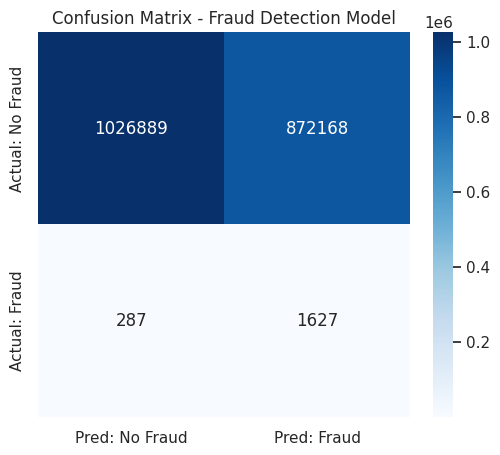

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

cm = np.array([
    [1026889, 872168],
    [287, 1627]
])

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No Fraud', 'Pred: Fraud'],
            yticklabels=['Actual: No Fraud', 'Actual: Fraud'])

plt.title("Confusion Matrix - Fraud Detection Model")
plt.show()
